In [103]:
# !pip install seaborn

# !pip install pandas scikit-learn torch transformers
!pip install nltk

In [104]:
!pip install xgboost

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [106]:
# df=pd.read_csv('tickets (2).csv')
df=pd.read_csv('expanded_tickets.csv')


df.head()

df=df[['subject','category','priority']]
df.shape

(1300, 3)

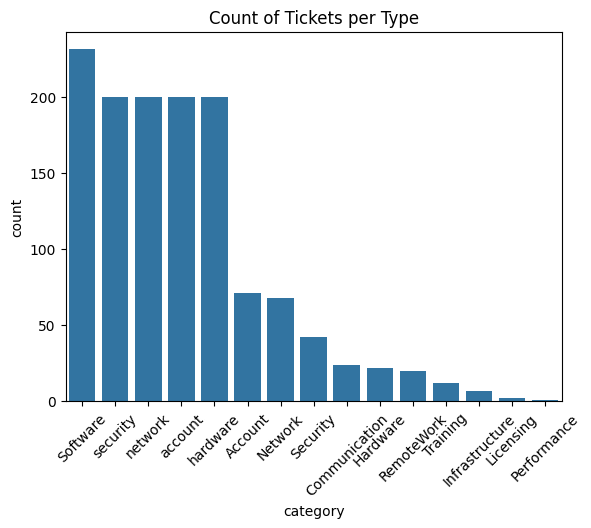

In [107]:
sns.countplot(data=df, x="category", order=df["category"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Count of Tickets per Type")
plt.show()


In [108]:

# data
# df_clean = df.dropna()

# df = df.dropna(subset=["category"])

df.category.isnull().sum()


np.int64(0)

In [109]:
df = df.dropna(subset=["category"])


In [110]:
df.category.isnull().sum()
# Should now be 0


np.int64(0)

In [111]:
# Remove specific categories
categories_to_remove = ['Training','Licensing','Infrastructure','Performance' ]
df= df[~df['category'].isin(categories_to_remove)]


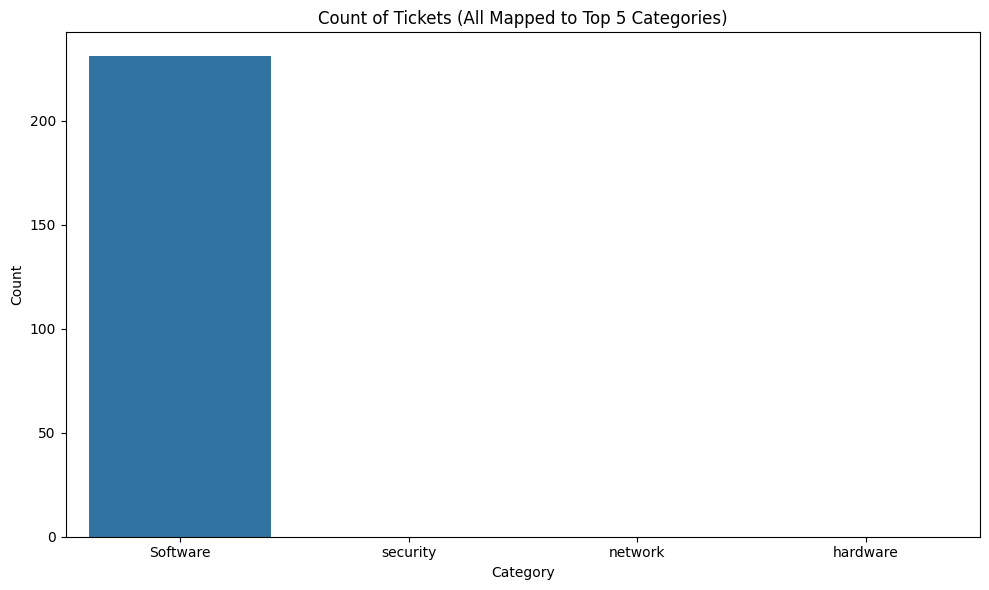

In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get top 5 categories
top4 = df['category'].value_counts().nlargest(4).index.tolist()

# Step 2: Manual mapping for other categories → closest top 5 category
custom_mapping = {
    'Software': 'Software',
    'Account': 'Account',
    'Network': 'Network',
    'Security': 'Security',
    'Communication': 'Network',
    'Hardware': 'Hardware',
    'RemoteWork': 'Network',
    # 'Training': 'Account',
    # 'Infrastructure': "Hardware",
    # 'Licensing': 'Software',
    # 'Performance': 'Software'
}

# Step 3: Apply mapping
df['category'] = df['category'].map(custom_mapping)


# # Step 4: Plot the converted categories
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', order=top4)
plt.title("Count of Tickets (All Mapped to Top 5 Categories)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


<Axes: xlabel='category', ylabel='count'>

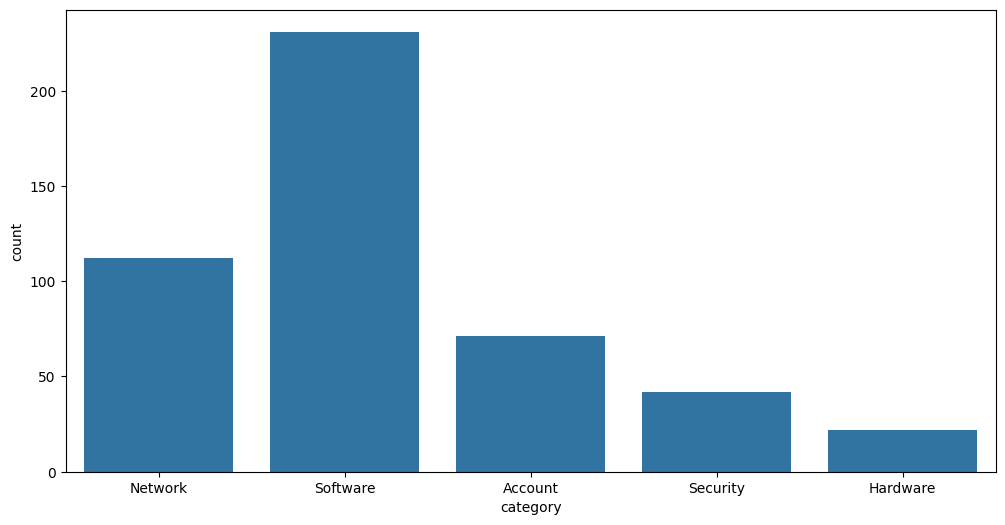

In [113]:
# Plot graph to check class imbalance
plt.figure(figsize=(12,6))
sns.countplot(x='category',data=df)


In [114]:
# df[df['category']=="Licensing"].iloc[1].subject
len(set(df['category']))

6

In [115]:
len(df[df['subject']==''])

0

In [116]:
# Write your function here to clean the text and remove all the unnecessary elements.
# Preparing text for Topic modelling
import re
import string
def clean_text(text):
    text = text.lower()  # Make the text lowercase
    text = re.sub('\[.*\]','', text).strip() # Remove text in square brackets
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub('\S*\d\S*\s*','', text).strip()  # Remove words containing numbers
    return text.strip()

In [117]:
print(df['subject'].dtype)
df['subject']=df['subject'].apply(lambda x:clean_text(str(x)))
# len(df[df['subject']==''])
# data


object


In [118]:
import nltk
import spacy
nltk.download('stopwords')
nlp=spacy.load('en_core_web_sm')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saiff\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [119]:
stop_words= {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves",
    "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was",
    "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and",
    "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between",
    "into", "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on",
    "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all",
    "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same",
    "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now", "d", "ll", "m", "o", "re",
    "ve", "y", "ain", "aren", "couldn", "didn", "doesn", "hadn", "hasn", "haven", "isn", "ma", "mightn", "mustn", "needn",
    "shan", "shouldn", "wasn", "weren", "won", "wouldn"
}



In [120]:
stopwords = nlp.Defaults.stop_words
def lemmatizer(text):
    doc = nlp(text)
    sent = [token.lemma_ for token in doc if not token.text in set(stopwords)]
    return ' '.join(sent)

In [121]:
df['lemma']=df.subject.apply(lambda x:lemmatizer(x))
df.head()

,subject,category,priority,lemma
0,hey it our network printer keeps disconnecting,Network,Medium,hey network printer keep disconnect
1,re re ticket access issue with shared network...,Network,High,ticket access issue share network drive
2,software conflict causing app crashes,Software,High,software conflict cause app crash
3,jdoeacmeco google calendar setup assistance,Software,Medium,jdoeacmeco google calendar setup assistance
4,software access asana project for jordan smith,Software,Medium,software access asana project jordan smith


In [122]:
def extract_pos_tags(text):
    doc = nlp(text)
    sent = [token.text for token in doc if token.tag_ == 'NN']
    return ' '.join(sent)

In [123]:
df['NN_tags']=df.subject.apply(lambda x: extract_pos_tags(x))

df.head()

,subject,category,priority,lemma,NN_tags
0,hey it our network printer keeps disconnecting,Network,Medium,hey network printer keep disconnect,network printer
1,re re ticket access issue with shared network...,Network,High,ticket access issue share network drive,ticket access issue network drive
2,software conflict causing app crashes,Software,High,software conflict cause app crash,software conflict app
3,jdoeacmeco google calendar setup assistance,Software,Medium,jdoeacmeco google calendar setup assistance,setup assistance
4,software access asana project for jordan smith,Software,Medium,software access asana project jordan smith,software asana project


(array([805.,   2.,   0.,   9.,   4.,   7.,   4.,  16.,  11.,  50.,  10.,
         27.,  19.,  44.,  19.,  33.,  13.,  29.,  20.,  20.,  10.,  28.,
          7.,  15.,  17.,  11.,  11.,  10.,  10.,   3.,   0.,   1.,   3.,
          1.,   2.,   0.,   1.,   1.,   1.,   0.,   1.,   0.,   1.,   0.,
          0.,   1.,   0.,   0.,   0.,   1.]),
 array([ 0.  ,  1.52,  3.04,  4.56,  6.08,  7.6 ,  9.12, 10.64, 12.16,
        13.68, 15.2 , 16.72, 18.24, 19.76, 21.28, 22.8 , 24.32, 25.84,
        27.36, 28.88, 30.4 , 31.92, 33.44, 34.96, 36.48, 38.  , 39.52,
        41.04, 42.56, 44.08, 45.6 , 47.12, 48.64, 50.16, 51.68, 53.2 ,
        54.72, 56.24, 57.76, 59.28, 60.8 , 62.32, 63.84, 65.36, 66.88,
        68.4 , 69.92, 71.44, 72.96, 74.48, 76.  ]),
 <BarContainer object of 50 artists>)

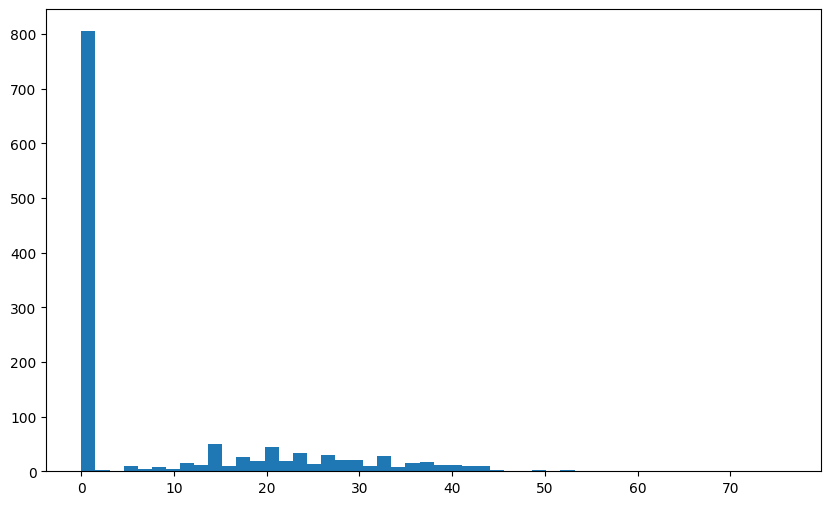

In [124]:
plt.figure(figsize=(10,6))
doc_lens = [len(d) for d in df.NN_tags]
plt.hist(doc_lens, bins = 50)

In [125]:
!pip install wordcloud


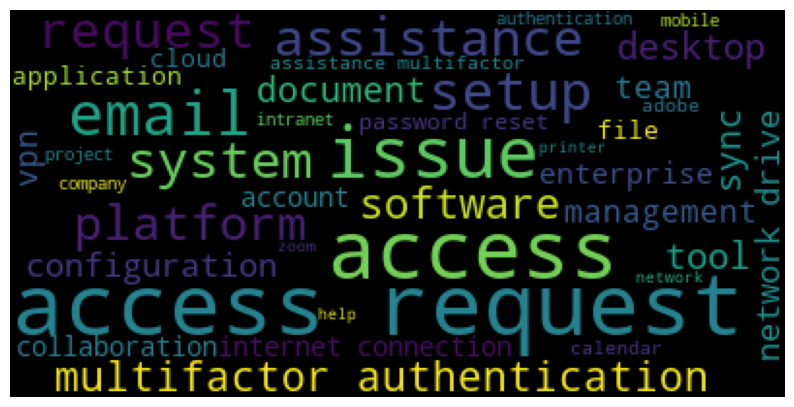

In [126]:
from wordcloud import WordCloud

wordcloud = WordCloud(stopwords=stopwords,max_words=40).generate(str(df.NN_tags))

print(wordcloud)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [127]:
import json 
import numpy as np
import pandas as pd
import re, nltk, spacy, string
import en_core_web_sm
nlp = en_core_web_sm.load()

#Importing libraries required for the case study and to plot charts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px
%matplotlib inline

#Importing Regular Expressions for String manipulation
import re

# hide warnings
import warnings
warnings.filterwarnings('ignore')

# set options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pprint import pprint




In [128]:
!pip install plotly

In [129]:
def get_top_n_bigram(text, ngram=1, top=None):
    vec = CountVectorizer(ngram_range=(ngram, ngram), stop_words='english').fit(text)
    bag_of_words = vec.transform(text)

    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top]

In [130]:
df_clean=df

In [131]:
top_30_unigrams = get_top_n_bigram(df_clean.NN_tags,ngram=1, top=30)
top_30_bigrams = get_top_n_bigram(df_clean.NN_tags,ngram=2, top=30)
top_30_trigrams = get_top_n_bigram(df_clean.NN_tags,ngram=3, top=30)

top 10 unigrams

In [132]:
top_30_unigrams[:10]

[('access', np.int64(175)),
 ('request', np.int64(123)),
 ('issue', np.int64(62)),
 ('assistance', np.int64(42)),
 ('email', np.int64(42)),
 ('setup', np.int64(36)),
 ('authentication', np.int64(28)),
 ('platform', np.int64(26)),
 ('network', np.int64(21)),
 ('software', np.int64(20))]

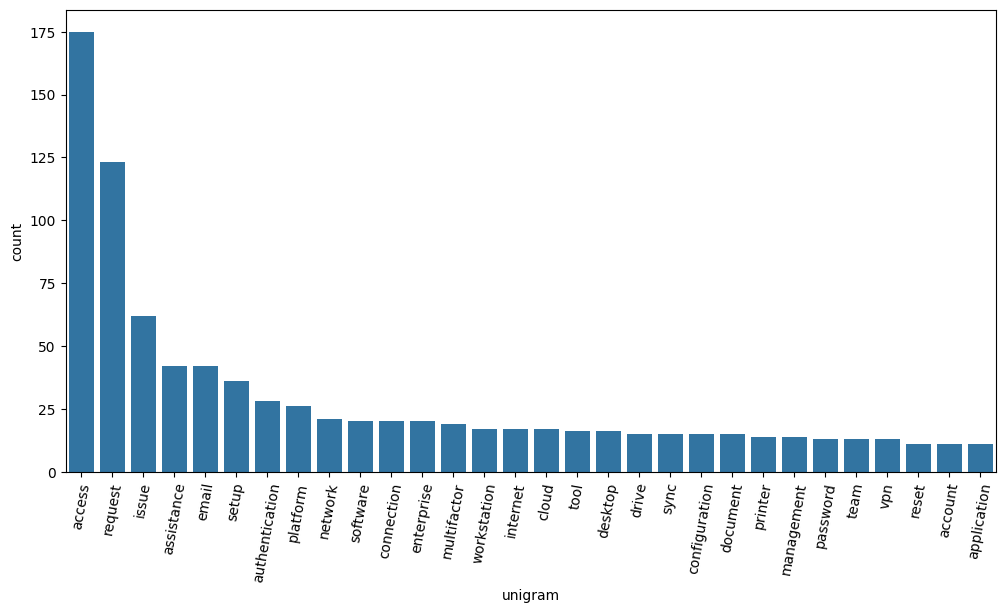

In [133]:
df1 = pd.DataFrame(top_30_unigrams, columns = ['unigram' , 'count'])
plt.figure(figsize=(12,6))
fig = sns.barplot(x=df1['unigram'], y=df1['count'])
plt.xticks(rotation = 80)
plt.show()

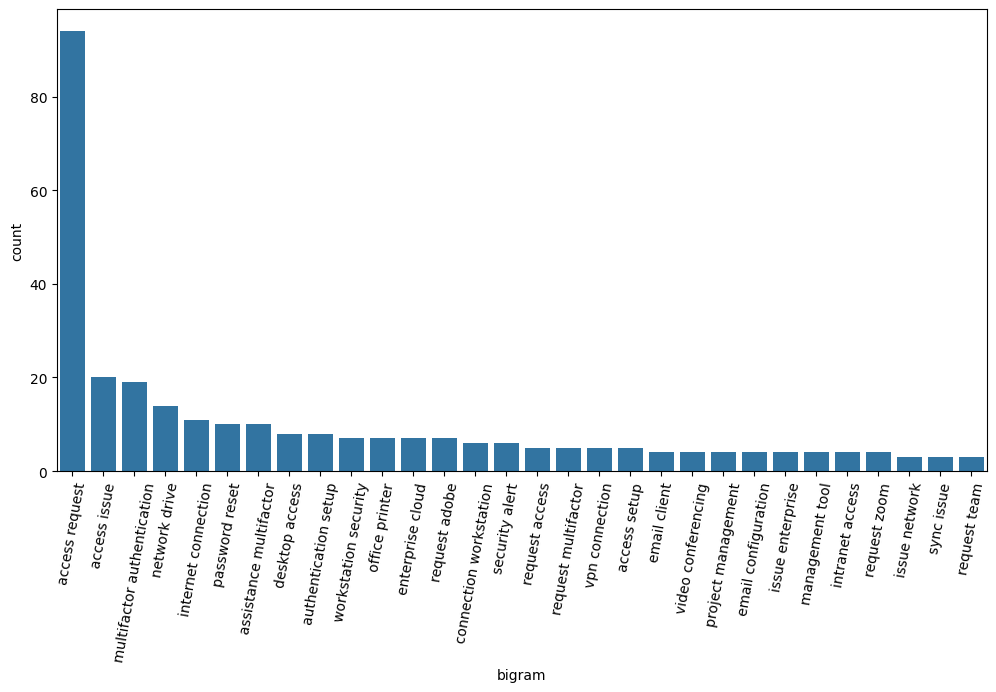

In [134]:
df2 = pd.DataFrame(top_30_bigrams, columns = ['bigram' , 'count'])
plt.figure(figsize=(12,6))
fig = sns.barplot(x=df2['bigram'], y=df2['count'])
plt.xticks(rotation = 80)
plt.show()

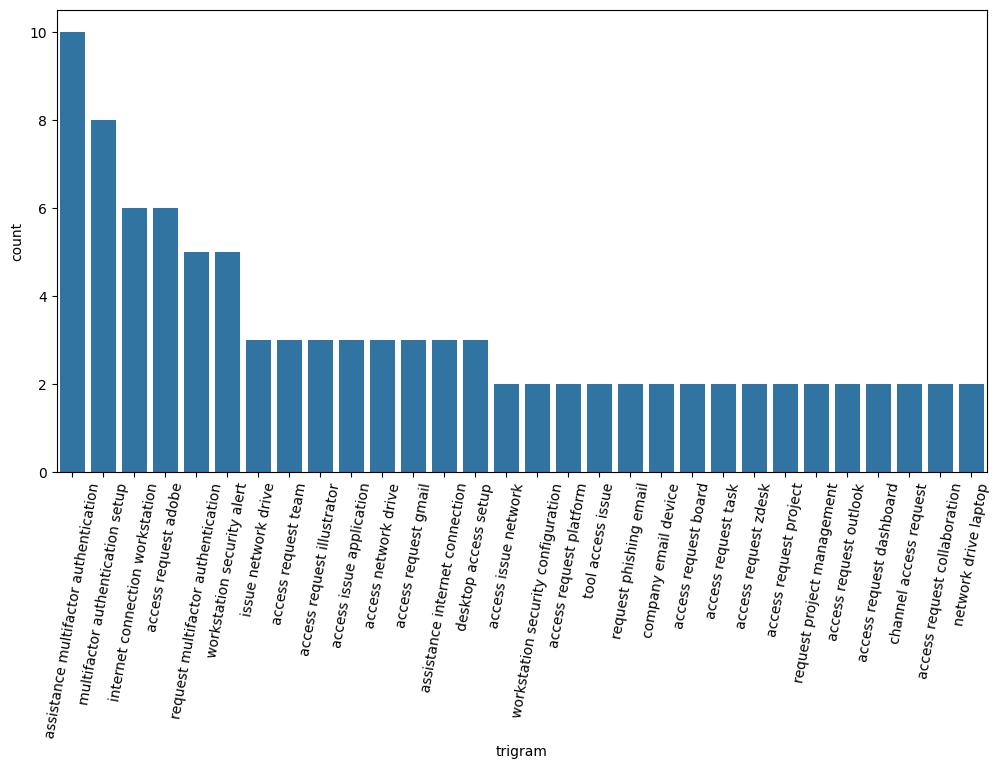

In [135]:
df3 = pd.DataFrame(top_30_trigrams, columns = ['trigram' , 'count'])
plt.figure(figsize=(12,6))
fig = sns.barplot(x=df3['trigram'], y=df3['count'])
plt.xticks(rotation = 80)
plt.show()


In [136]:
tfidf = TfidfVectorizer(min_df=2, max_df=0.95, stop_words='english')

In [137]:
dtm = tfidf.fit_transform(df_clean.NN_tags) 

In [138]:
print(len(tfidf.get_feature_names_out()))
tfidf.get_feature_names_out()[:10]


145


array(['access', 'account', 'acrobat', 'adjustment', 'admin', 'adobe',
       'alert', 'app', 'application', 'asana'], dtype=object)

<Axes: xlabel='category', ylabel='count'>

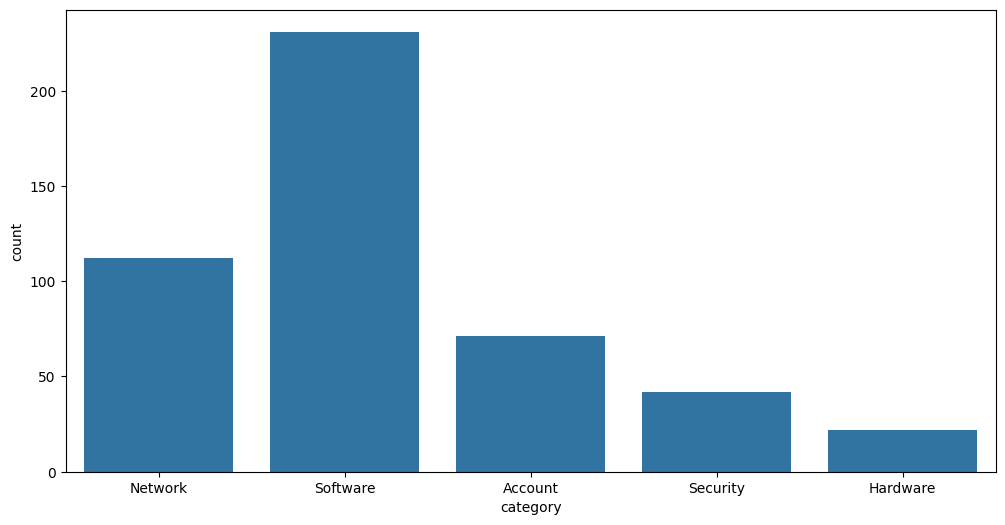

In [139]:
# Plot graph to check class imbalance
plt.figure(figsize=(12,6))
sns.countplot(x='category',data=df)


In [140]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_fscore_support

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [141]:
# utlity function to display the model report

def display_classification_report(model,metric):
    
    y_train_pred_proba = model.predict_proba(X_train)
    y_test_pred_proba = model.predict_proba(X_test)
    roc_auc_score_train = round(roc_auc_score(y_train, y_train_pred_proba,average='weighted',multi_class='ovr'),2)
    roc_auc_score_test = round(roc_auc_score(y_test, y_test_pred_proba,average='weighted',multi_class='ovr'),2)
    print("ROC AUC Score Train:", roc_auc_score_train)
    print("ROC AUC Score Test:", roc_auc_score_test)
    metric.append(roc_auc_score_train)
    metric.append(roc_auc_score_test)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
  
    precision_train,recall_train,fscore_train,support_train=precision_recall_fscore_support(y_train,y_train_pred,average='weighted')
    precision_test,recall_test,fscore_test,support_test=precision_recall_fscore_support(y_test,y_test_pred,average='weighted')
    
    acc_score_train = round(accuracy_score(y_train,y_train_pred),2)
    acc_score_test = round(accuracy_score(y_test,y_test_pred),2)
    
    metric.append(acc_score_train)
    metric.append(acc_score_test)
    metric.append(round(precision_train,2))
    metric.append(round(precision_test,2))
    metric.append(round(recall_train,2))
    metric.append(round(recall_test,2))
    metric.append(round(fscore_train,2))
    metric.append(round(fscore_test,2))
    
    print('Train Accuracy :',acc_score_train)
    print('Test Accuracy :',acc_score_test)
        
    model_report_train = classification_report(y_train,y_train_pred)
    model_report_test = classification_report(y_test,y_test_pred)
    
    print('Classification Report for Train:\n',model_report_train)
    print('Classification Report for Test:\n',model_report_test)


    # Plot the confusion matrix
    fig, ax = plt.subplots(figsize=(12, 8))
    # Create the confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    cmp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    cmp.plot(ax=ax)
    plt.xticks(rotation=80)

    plt.show();

In [142]:
df=df.dropna(subset=['subject','category'])

In [143]:
# x - y  split
X = df.NN_tags
y = df.category
count_vect = CountVectorizer()
X_vect = count_vect.fit_transform(X)

In [144]:
from sklearn.feature_extraction.text import TfidfTransformer
#Write your code here to transform the word vector to tf-idf
#Fit transform word vector to TF-IDF
tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_vect)

In [145]:
# import numpy as np

# print("NaNs in X_tfidf:", np.any(pd.DataFrame(X_tfidf).isnull()))
# print("NaNs in y:", y.isnull().sum())


In [146]:
# Convert X_tfidf to DataFrame if needed
# X_df = pd.DataFrame(X_tfidf)

# # Combine into single DataFrame for safe cleaning
# combined = pd.concat([X_df, y.reset_index(drop=True)], axis=1)

# # Drop rows with NaNs
# combined_clean = combined.dropna()

# # Split back into X and y
# X_clean = combined_clean.iloc[:, :-1]
# y_clean = combined_clean.iloc[:, -1]


In [147]:
from sklearn.model_selection import train_test_split
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.25, random_state=40, stratify=y)

OOB SCORE : 0.48324022346368717
ROC AUC Score Train: 0.84
ROC AUC Score Test: 0.53
Train Accuracy : 0.48
Test Accuracy : 0.48
Classification Report for Train:
               precision    recall  f1-score   support

     Account       0.00      0.00      0.00        53
    Hardware       0.00      0.00      0.00        17
     Network       0.00      0.00      0.00        84
    Security       0.00      0.00      0.00        31
    Software       0.48      1.00      0.65       173

    accuracy                           0.48       358
   macro avg       0.10      0.20      0.13       358
weighted avg       0.23      0.48      0.31       358

Classification Report for Test:
               precision    recall  f1-score   support

     Account       0.00      0.00      0.00        18
    Hardware       0.00      0.00      0.00         5
     Network       0.00      0.00      0.00        28
    Security       0.00      0.00      0.00        11
    Software       0.48      1.00      0.65    

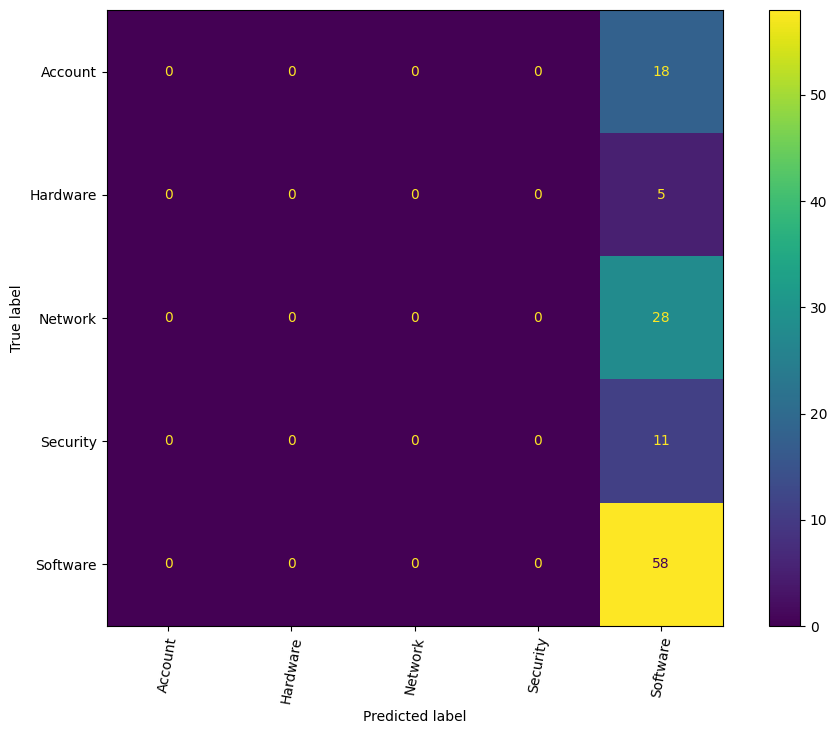

In [191]:

rf = RandomForestClassifier(n_estimators = 500,oob_score=True,
                            max_depth=20,min_samples_leaf=5)
# fit model
rf.fit(X_train,y_train)

# oob score
print('OOB SCORE :',rf.oob_score_)

# Random Forest Classification Report
metric4=[]
display_classification_report(rf,metric4)

In [149]:
X,y

(0                                        network printer
 1                      ticket access issue network drive
 2                                  software conflict app
 3                                       setup assistance
 4                                 software asana project
 5                                email client sync issue
 6                          access request storage folder
 7                assistance password reset email account
 9      workstation security configuration inconsisten...
 10                                    authentication mfa
 11                                        access request
 12            inconsistent connectivity network analysis
 13     access issue web application browser compatibi...
 15                                  slack access request
 17                                      profile intranet
 18                            access request team folder
 19     internet connection office floor network asses...
 20           

In [150]:
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 40)

In [151]:
def grid_search(model,folds,params,scoring):
    
    grid_search = GridSearchCV(model,
                                cv=folds, 
                                param_grid=params, 
                                scoring=scoring, 
                                n_jobs=-1, verbose=1)
    return grid_search

In [152]:
def print_best_score_params(model):
    print("Best Score: ", model.best_score_)
    print("Best Hyperparameters: ", model.best_params_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
OOB SCORE : 0.5810055865921788
Best Score:  0.8676191139398952
Best Hyperparameters:  {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 500}
ROC AUC Score Train: 0.91
ROC AUC Score Test: 0.86
Train Accuracy : 0.58
Test Accuracy : 0.58
Classification Report for Train:
               precision    recall  f1-score   support

     Account       0.00      0.00      0.00        53
    Hardware       0.00      0.00      0.00        17
     Network       1.00      0.26      0.42        84
    Security       1.00      0.39      0.56        31
    Software       0.53      1.00      0.70       173

    accuracy                           0.58       358
   macro avg       0.51      0.33      0.33       358
weighted avg       0.58      0.58      0.48       358

Classification Report for Test:
               precision    recall  f1-score   support

     Account       0.00      0.00      0.00        18
    Hardware       0.00      0.

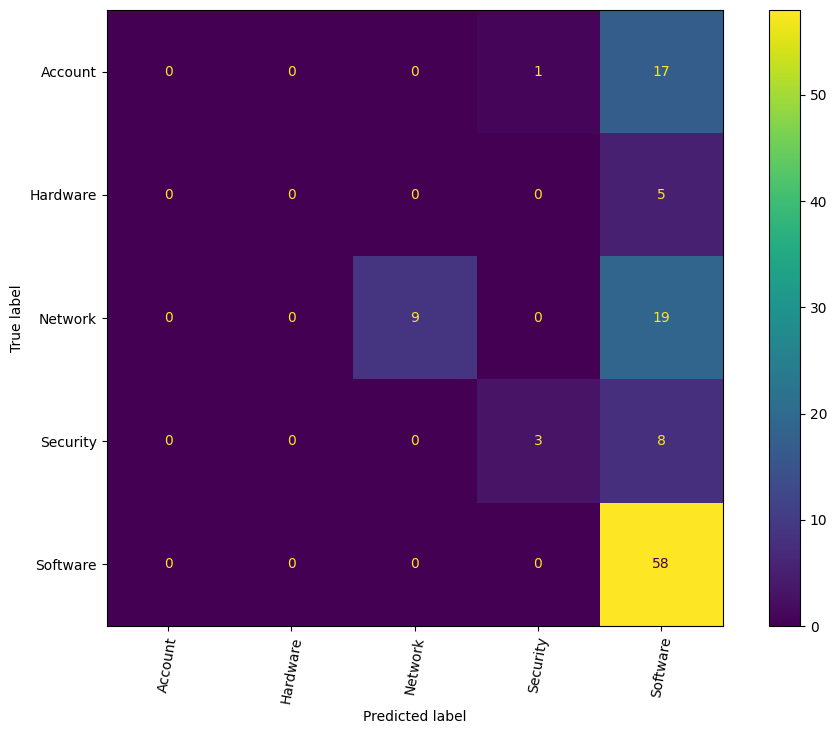

In [153]:

rfc = RandomForestClassifier(random_state=40, n_jobs = -1,oob_score=True)

# hyperparameters for Random Forest
rfc_params = {'max_depth': [10,20,30,40],
          'min_samples_leaf': [5,10,15,20,30],
          'n_estimators': [100,200,500,700]
        }

# create gridsearch object
grid_search_rfc = grid_search(rfc, folds, rfc_params, scoring='roc_auc_ovr')

# fit model
grid_search_rfc.fit(X_train, y_train)

# oob score
print('OOB SCORE :',grid_search_rfc.best_estimator_.oob_score_)

# print best hyperparameters
print_best_score_params(grid_search_rfc)

# Random Forest Classification Report
metric8=[]
display_classification_report(grid_search_rfc,metric8)

ROC AUC Score Train: 0.97
ROC AUC Score Test: 0.89
Train Accuracy : 0.77
Test Accuracy : 0.72
Classification Report for Train:
               precision    recall  f1-score   support

     Account       0.82      0.51      0.63        53
    Hardware       0.91      0.59      0.71        17
     Network       0.98      0.65      0.79        84
    Security       0.81      0.55      0.65        31
    Software       0.70      0.96      0.81       173

    accuracy                           0.77       358
   macro avg       0.84      0.65      0.72       358
weighted avg       0.80      0.77      0.76       358

Classification Report for Test:
               precision    recall  f1-score   support

     Account       0.67      0.22      0.33        18
    Hardware       0.00      0.00      0.00         5
     Network       0.95      0.71      0.82        28
    Security       0.83      0.45      0.59        11
    Software       0.66      0.98      0.79        58

    accuracy            

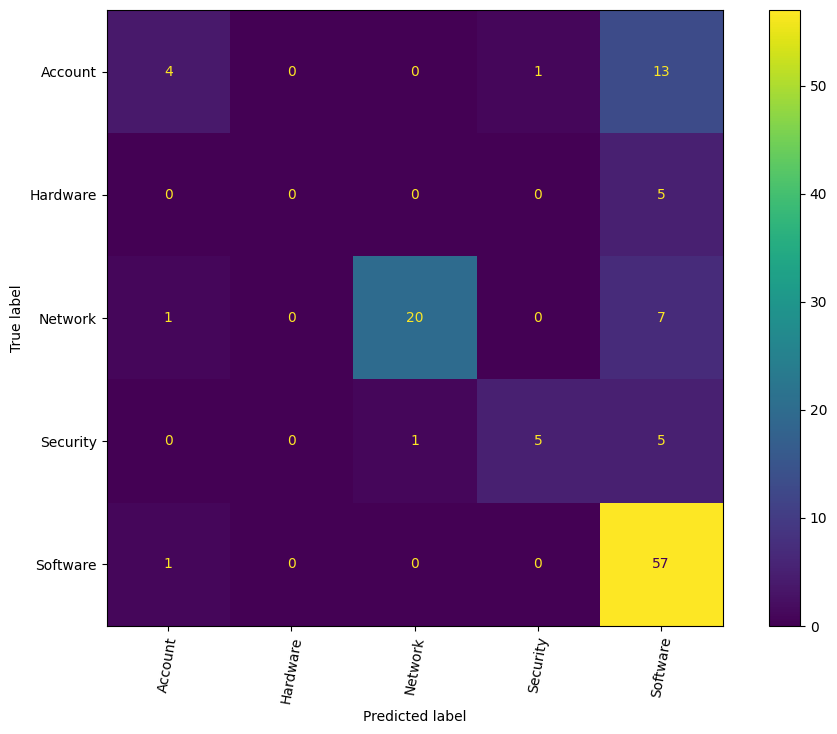

In [154]:
# Logistic Regression Classification
log_reg = LogisticRegression(random_state=40,solver='liblinear')
# fit model
log_reg.fit(X_train,y_train)
# display classification report
metric2=[]
display_classification_report(log_reg,metric2)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Score:  0.7093896713615023
Best Hyperparameters:  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
ROC AUC Score Train: 0.99
ROC AUC Score Test: 0.87
Train Accuracy : 0.94
Test Accuracy : 0.74
Classification Report for Train:
               precision    recall  f1-score   support

     Account       0.89      0.92      0.91        53
    Hardware       0.94      1.00      0.97        17
     Network       0.97      0.93      0.95        84
    Security       0.90      0.90      0.90        31
    Software       0.95      0.95      0.95       173

    accuracy                           0.94       358
   macro avg       0.93      0.94      0.94       358
weighted avg       0.94      0.94      0.94       358

Classification Report for Test:
               precision    recall  f1-score   support

     Account       0.67      0.33      0.44        18
    Hardware       1.00      0.60      0.75         5
     Network       0.

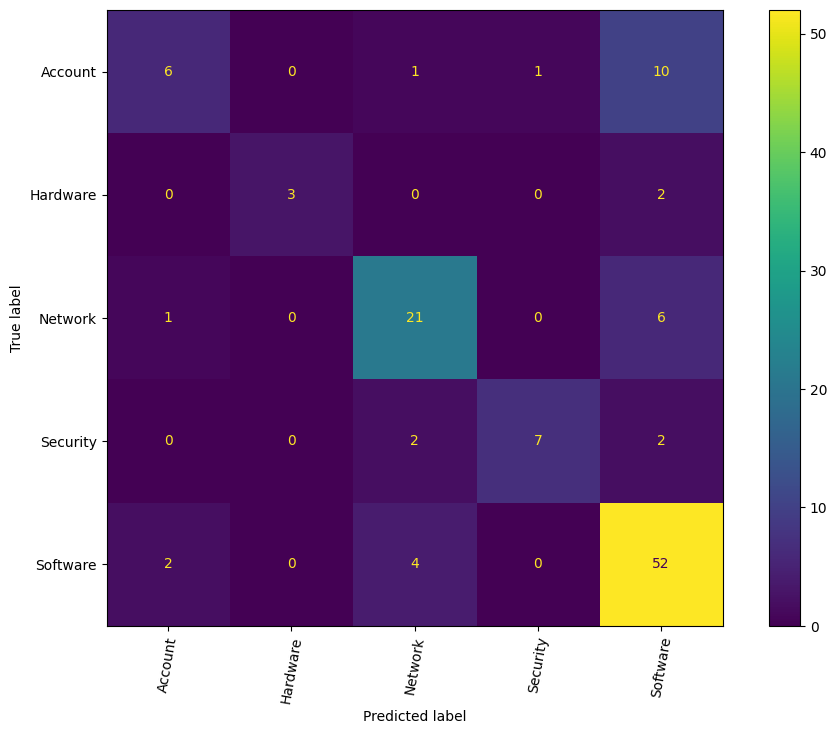

In [155]:
# logistic regression
log_reg = LogisticRegression()

# hyperparameter for Logistic Regression
log_params = {'C': [0.01, 1, 10], 
          'penalty': ['l1', 'l2'],
          'solver': ['liblinear','newton-cg','saga']
         }

# create gridsearch object
grid_search_log = grid_search(log_reg, folds, log_params, scoring=None)

# fit model
grid_search_log.fit(X_train, y_train)

# print best hyperparameters
print_best_score_params(grid_search_log)

# Random Forest Classification Report
metric6=[]
display_classification_report(grid_search_log,metric6)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Score:  0.7865187172693547
Best Hyperparameters:  {'max_depth': 30, 'min_samples_leaf': 5}
ROC AUC Score Train: 0.92
ROC AUC Score Test: 0.78
Train Accuracy : 0.77
Test Accuracy : 0.62
Classification Report for Train:
               precision    recall  f1-score   support

     Account       0.64      0.68      0.66        53
    Hardware       0.83      0.59      0.69        17
     Network       0.85      0.69      0.76        84
    Security       0.81      0.68      0.74        31
    Software       0.77      0.87      0.81       173

    accuracy                           0.77       358
   macro avg       0.78      0.70      0.73       358
weighted avg       0.77      0.77      0.77       358

Classification Report for Test:
               precision    recall  f1-score   support

     Account       0.56      0.50      0.53        18
    Hardware       0.00      0.00      0.00         5
     Network       0.62      0

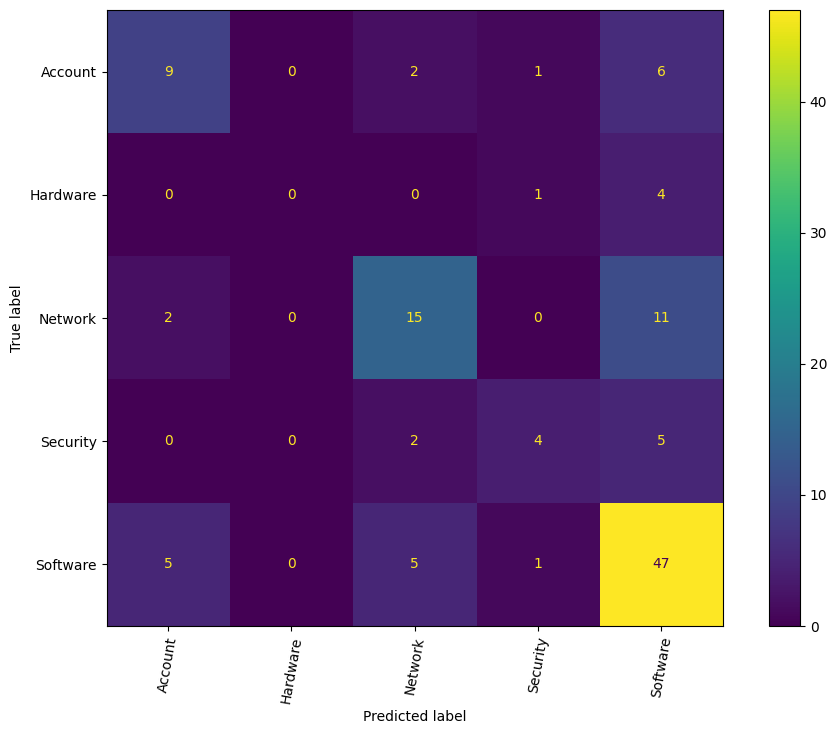

In [157]:
dtc = DecisionTreeClassifier(random_state=40)

dtc_params = {
    'max_depth': [5,10,20,30],
    'min_samples_leaf': [5,10,20,30]
}

# create gridsearch object
grid_search_dtc = grid_search(dtc, folds, dtc_params, scoring='roc_auc_ovr')

# fit model
grid_search_dtc.fit(X_train, y_train)

# print best hyperparameters
print_best_score_params(grid_search_dtc)

# Random Forest Classification Report
metric7=[]
display_classification_report(grid_search_dtc,metric7)

<Axes: xlabel='category', ylabel='count'>

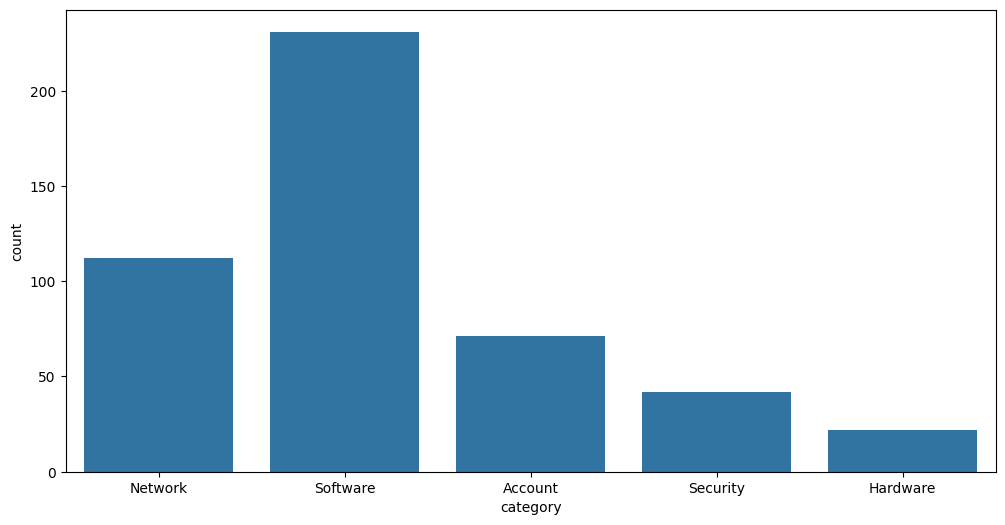

In [158]:
# Plot graph to check class imbalance
plt.figure(figsize=(12,6))
sns.countplot(x='category',data=df)


In [159]:
from transformers import pipeline

# Load sentiment-analysis pipeline
classifier = pipeline("sentiment-analysis")

# Sample texts
texts = [
    "I love this product! It works perfectly.",
    "This is the worst experience I've ever had.",
    "Meh, it was okay I guess."
]

# Run sentiment analysis
results = classifier(texts)


for text, result in zip(texts, results):
    print(f"Text: {text}")
    print(f"Sentiment: {result['label']}, Confidence: {result['score']:.4f}\n")


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


Text: I love this product! It works perfectly.
Sentiment: POSITIVE, Confidence: 0.9999

Text: This is the worst experience I've ever had.
Sentiment: NEGATIVE, Confidence: 0.9998

Text: Meh, it was okay I guess.
Sentiment: POSITIVE, Confidence: 0.9996



In [160]:
query = input("Enter your ticket subject: ")

cleaned_query = clean_text(query)
processed_query = extract_pos_tags(cleaned_query)

query_vect = count_vect.transform([processed_query]) 
query_tfidf = tfidf_transformer.transform(query_vect)  

predicted_category = rf.predict(query_tfidf)[0]

print(f"Processed Query (Nouns): {processed_query}")
print(f"Predicted Category: {predicted_category}")



Processed Query (Nouns): 
Predicted Category: Software


In [161]:
relevant_keywords = {
    "Network": [
        "wifi", "ethernet", "LAN", "VPN", "IP address", "DNS", "connection",
        "firewall", "switch", "router", "network printer", "packet loss",
        "slow internet", "disconnected", "signal strength"
    ],
    "Software": [
        "installation", "update", "crash", "not responding", "compatibility",
        "license", "activation", "configuration", "patch", "plugin", "error code",
        "application", "performance issue", "login problem", "settings"
    ],
    "Hardware": [
        "monitor", "keyboard", "mouse", "printer", "scanner", "CPU", "RAM",
        "hard drive", "SSD", "fan", "overheating", "device not detected",
        "port issue", "broken screen", "peripheral"
    ],
    "Account": [
        "login", "password", "reset", "MFA", "locked", "disabled", "user profile",
        "sign in", "forgot password", "email not syncing", "credentials",
        "permissions", "access request", "new user setup", "account creation"
    ],
    "Security": [
        "antivirus", "malware", "phishing", "firewall", "breach",
        "suspicious activity", "unauthorized access", "encryption", "VPN",
        "2FA", "data leak", "password policy", "security alert", "threat",
        "patch update"
    ]
}


In [162]:
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Create base models
model_nb = MultinomialNB()
model_lr = LogisticRegression(max_iter=1000, solver='liblinear')
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# VotingClassifier with soft voting (recommended if models support predict_proba)
voting_clf = VotingClassifier(
    estimators=[
        ('naive_bayes', model_nb),
        ('log_reg', model_lr),
        ('random_forest', model_rf)
    ],
    voting='soft'
)

# Fit on training data
voting_clf.fit(X_train, y_train)

# Predict on test data
y_pred_ensemble = voting_clf.predict(X_test)
y_pred_proba_ensemble = voting_clf.predict_proba(X_test)

# Evaluate performance
print("Ensemble Model Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("Classification Report:\n", classification_report(y_test, y_pred_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))

# ROC AUC score (optional)
try:
    auc_ensemble = roc_auc_score(y_test, y_pred_proba_ensemble, multi_class='ovr', average='weighted')
    print("Ensemble ROC AUC Score:", auc_ensemble)
except Exception as e:
    print("AUC Score Error:", e)


Ensemble Model Accuracy: 0.7416666666666667
Classification Report:
               precision    recall  f1-score   support

     Account       0.80      0.22      0.35        18
    Hardware       1.00      0.20      0.33         5
     Network       0.95      0.75      0.84        28
    Security       0.83      0.45      0.59        11
    Software       0.67      1.00      0.81        58

    accuracy                           0.74       120
   macro avg       0.85      0.53      0.58       120
weighted avg       0.79      0.74      0.71       120

Confusion Matrix:
 [[ 4  0  0  1 13]
 [ 0  1  0  0  4]
 [ 1  0 21  0  6]
 [ 0  0  1  5  5]
 [ 0  0  0  0 58]]
Ensemble ROC AUC Score: 0.8798682202903765


In [164]:
relevant_keywords = {
    "Network": [
        "wifi", "ethernet", "LAN", "VPN", "IP address", "DNS", "connection",
        "firewall", "switch", "router", "network printer", "packet loss",
        "slow internet", "disconnected", "signal strength"
    ],
    "Software": [
        "installation", "update", "crash", "not responding", "compatibility",
        "license", "activation", "configuration", "patch", "plugin", "error code",
        "application", "performance issue", "login problem", "settings"
    ],
    "Hardware": [
        "monitor", "keyboard", "mouse", "printer", "scanner", "CPU", "RAM",
        "hard drive", "SSD", "fan", "overheating", "device not detected",
        "port issue", "broken screen", "peripheral"
    ],
    "Account": [
        "login", "password", "reset", "MFA", "locked", "disabled", "user profile",
        "sign in", "forgot password", "email not syncing", "credentials",
        "permissions", "access request", "new user setup", "account creation"
    ],
    "Security": [
        "antivirus", "malware", "phishing", "firewall", "breach",
        "suspicious activity", "unauthorized access", "encryption", "VPN",
        "2FA", "data leak", "password policy", "security alert", "threat",
        "patch update"
    ]
}

In [187]:
import re
from sklearn.base import BaseEstimator, ClassifierMixin

# Convert keyword list into regex-friendly patterns
category_patterns = {
    category: [re.escape(keyword) for keyword in keywords]
    for category, keywords in relevant_keywords.items()
}


In [186]:
import re
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin

class RegExpClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, category_patterns):
        self.category_patterns = relevant_keywords
        self.classes_ = np.array(list(category_patterns.keys()) + ["Unknown"])

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        predictions = []
        for text in X:
            matched = False
            for category, patterns in self.category_patterns.items():
                for pattern in patterns:
                    if re.search(pattern, text, re.IGNORECASE):
                        predictions.append(category)
                        matched = True
                        break
                if matched:
                    break
            if not matched:
                predictions.append("Unknown")
        return np.array(predictions)

    def get_params(self, deep=True):
        return {"category_patterns": self.category_patterns}
